# Exercise 2: PCA

In this exercise, we will be using the same extracted "Bank Marketing" dataset, "bank-200.csv", from the K-Means exercise.

Your task now is to perform a dimension reduction on the provided dataset using the scikit-learn library and then build a model using K-Means. The process should include steps like data exploration, cleaning (if necessary), model building, and etc.

## Task 1 - Data Exploration
- Load the dataset and perform basic data exploration.
- Clean the dataset if necessary.

In [170]:
# Import the libraries

import os
from collections import OrderedDict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import seaborn as sns


In [146]:
import warnings
# Ignore FutureWarnings
warnings.filterwarnings("ignore", category=FutureWarning)
# Ignore UserWarnings
warnings.filterwarnings("ignore", category=UserWarning)

# import dataset
df = pd.read_csv('bank-200 - Copy.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        200 non-null    int64 
 1   job        200 non-null    object
 2   marital    200 non-null    object
 3   education  200 non-null    object
 4   default    200 non-null    object
 5   balance    200 non-null    int64 
 6   housing    200 non-null    object
 7   loan       200 non-null    object
 8   contact    200 non-null    object
 9   day        200 non-null    int64 
 10  month      200 non-null    object
 11  duration   200 non-null    int64 
 12  campaign   200 non-null    int64 
 13  pdays      200 non-null    int64 
 14  previous   200 non-null    int64 
 15  poutcome   200 non-null    object
 16  y          200 non-null    object
dtypes: int64(7), object(10)
memory usage: 26.7+ KB


In [147]:
print("     NULL        ")
print(df.isnull().sum())
print("")
print("     DUPLICATES        ")
print(df.duplicated().sum())

     NULL        
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

     DUPLICATES        
0


## Task 2 - Data Visualization
- Perform some basic data visualization on the dataset to gain more insight on the dataset.

In [148]:
numeric_df = df.iloc[:, [0, 5, 9, 11, 12, 13, 14]]
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,57,retired,divorced,secondary,no,39,yes,no,cellular,30,jul,354,3,-1,0,unknown,no
196,27,blue-collar,single,secondary,no,5563,yes,no,unknown,30,may,435,2,-1,0,unknown,no
197,38,services,married,secondary,no,1,no,yes,cellular,21,nov,152,2,-1,0,unknown,no
198,42,technician,married,tertiary,no,782,no,no,cellular,3,apr,285,1,-1,0,unknown,no


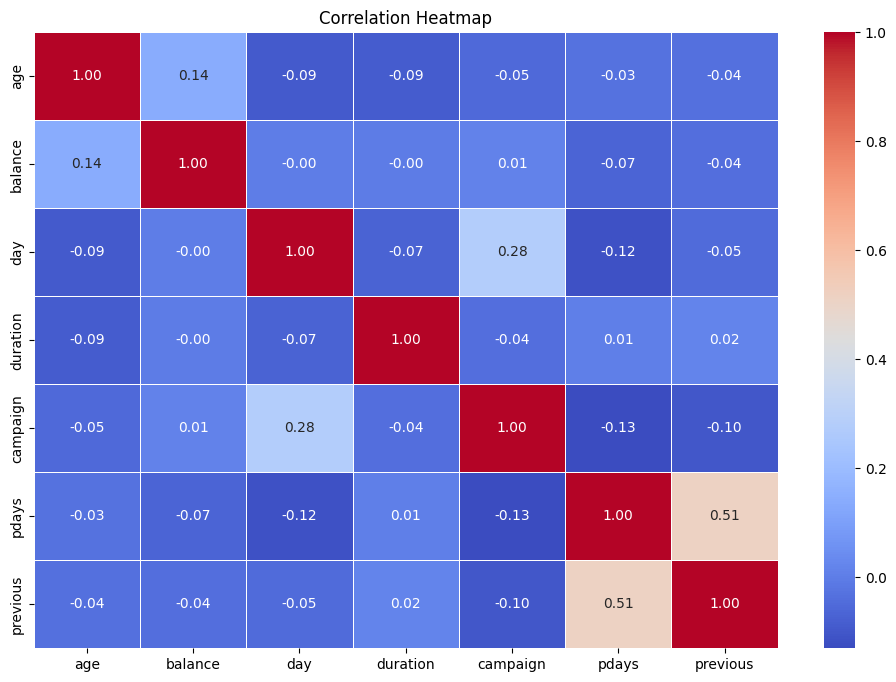

In [149]:
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

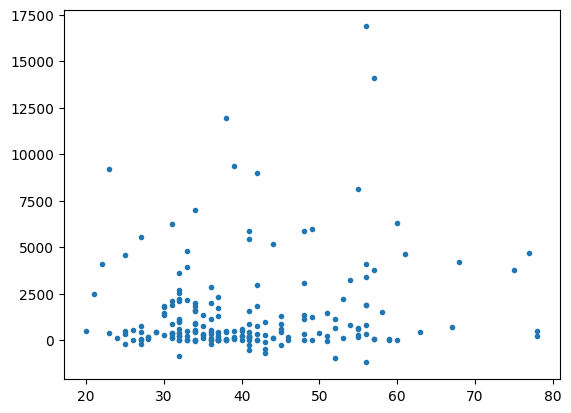

In [150]:
plt.scatter(numeric_df['age'], numeric_df['balance'], marker= '.')

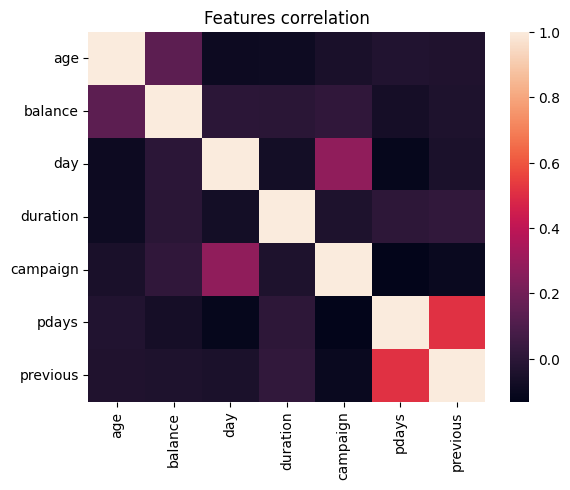

In [151]:
sns.heatmap(numeric_df.corr())
plt.title("Features correlation")
plt.show()

In [152]:
y = df['y']
y.head()

,y
0,no
1,no
2,no
3,no
4,no


In [153]:
df = df.drop(columns=['y'])
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown


## Task 3 - Scaling and Encoding
- Scale and encode the features if required.

![image.png](attachment:image.png)

In [154]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
numerical_features


Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')

In [155]:
numerical_scaled = StandardScaler().fit_transform(df[numerical_features])
df[numerical_features] = numerical_scaled
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,-0.927429,unemployed,married,primary,no,0.145232,no,no,cellular,0.366131,oct,-0.721117,-0.645939,-0.433610,-0.311003,unknown
1,-0.659515,services,married,secondary,no,1.350633,yes,yes,cellular,-0.598959,may,-0.145562,-0.645939,2.975510,1.950835,failure
2,-0.480906,management,single,tertiary,no,-0.030237,yes,no,cellular,0.004222,apr,-0.288430,-0.645939,2.885269,0.254457,failure
3,-0.927429,management,married,tertiary,no,0.020356,yes,yes,unknown,-1.564050,jun,-0.231283,0.910540,-0.433610,-0.311003,unknown
4,1.662406,blue-collar,married,secondary,no,-0.572306,yes,no,unknown,-1.322777,may,-0.121071,-0.645939,-0.433610,-0.311003,unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,1.483797,retired,divorced,secondary,no,-0.556646,yes,no,cellular,1.693131,jul,0.401419,0.391714,-0.433610,-0.311003,unknown
196,-1.195343,blue-collar,single,secondary,no,1.661419,yes,no,unknown,1.693131,may,0.732056,-0.127112,-0.433610,-0.311003,unknown
197,-0.212992,services,married,secondary,no,-0.571905,no,yes,cellular,0.607404,nov,-0.423135,-0.127112,-0.433610,-0.311003,unknown
198,0.144227,technician,married,tertiary,no,-0.258308,no,no,cellular,-1.564050,apr,0.119764,-0.645939,-0.433610,-0.311003,unknown


In [156]:
binary_cols = ["default", "housing", "loan"]
multi_category_cols = ["job", "marital", "education", "contact", "day", "month", "poutcome"]

multi_category_cols = [col for col in multi_category_cols if col in df.columns]

OHencoder = OneHotEncoder(drop="first", sparse_output=False)
OHencoded_features = OHencoder.fit_transform(df[multi_category_cols])
OHencoded_df = pd.DataFrame(OHencoded_features, columns=OHencoder.get_feature_names_out(multi_category_cols))

df = df.drop(columns=multi_category_cols)
df = pd.concat([df, OHencoded_df], axis=1)

for col in binary_cols:
    lencoder = LabelEncoder()
    df[col] = lencoder.fit_transform(df[col])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 68 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       200 non-null    float64
 1   default                   200 non-null    int64  
 2   balance                   200 non-null    float64
 3   housing                   200 non-null    int64  
 4   loan                      200 non-null    int64  
 5   duration                  200 non-null    float64
 6   campaign                  200 non-null    float64
 7   pdays                     200 non-null    float64
 8   previous                  200 non-null    float64
 9   job_blue-collar           200 non-null    float64
 10  job_entrepreneur          200 non-null    float64
 11  job_housemaid             200 non-null    float64
 12  job_management            200 non-null    float64
 13  job_retired               200 non-null    float64
 14  job_self-e

## Task 4 - Perform PCA and Model Building
- Reduce the dimensions of the data to 2 and build your K-means model from there.

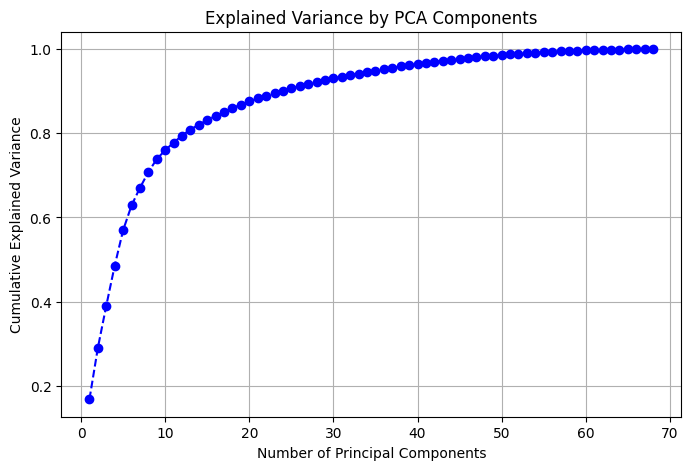

In [157]:
pca = PCA()
pca_result = pca.fit_transform(df)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Plot explained variance to find "elbow point"
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker="o", linestyle="--", color="b")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by PCA Components")
plt.grid()
plt.show()

In [158]:
# seems 10 is a good number
pca = PCA(n_components=10)
pca_result = pca.fit_transform(df)
pca_result

array([[-0.36515758, -0.10578901, -0.19905259, ...,  0.37097088,
         0.87980941, -0.40009923],
       [ 3.45387541,  0.89081036,  0.08974042, ...,  0.09389289,
         0.41202104,  0.23852147],
       [ 2.61823076, -0.10231453, -0.1781606 , ..., -1.03646369,
        -0.40247031,  0.28080145],
       ...,
       [-0.51528477, -0.106351  , -0.49673911, ...,  0.92727316,
         0.53801826,  0.00596981],
       [-0.42495641,  0.10956675,  0.34952197, ..., -0.12813896,
         0.71032789, -0.21446425],
       [ 1.23433356,  3.60341637,  0.34647675, ...,  0.42859396,
        -0.49803299, -0.1776582 ]])

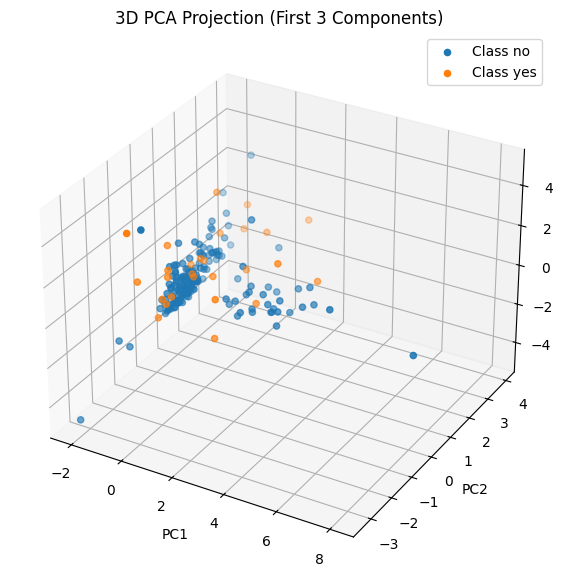

In [159]:
# 3D Scatter Plot using the first 3 principal components
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for label in np.unique(y):
    ax.scatter(pca_result[y == label, 0], pca_result[y == label, 1], pca_result[y == label, 2], label=f'Class {label}')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D PCA Projection (First 3 Components)')
ax.legend()
plt.show()

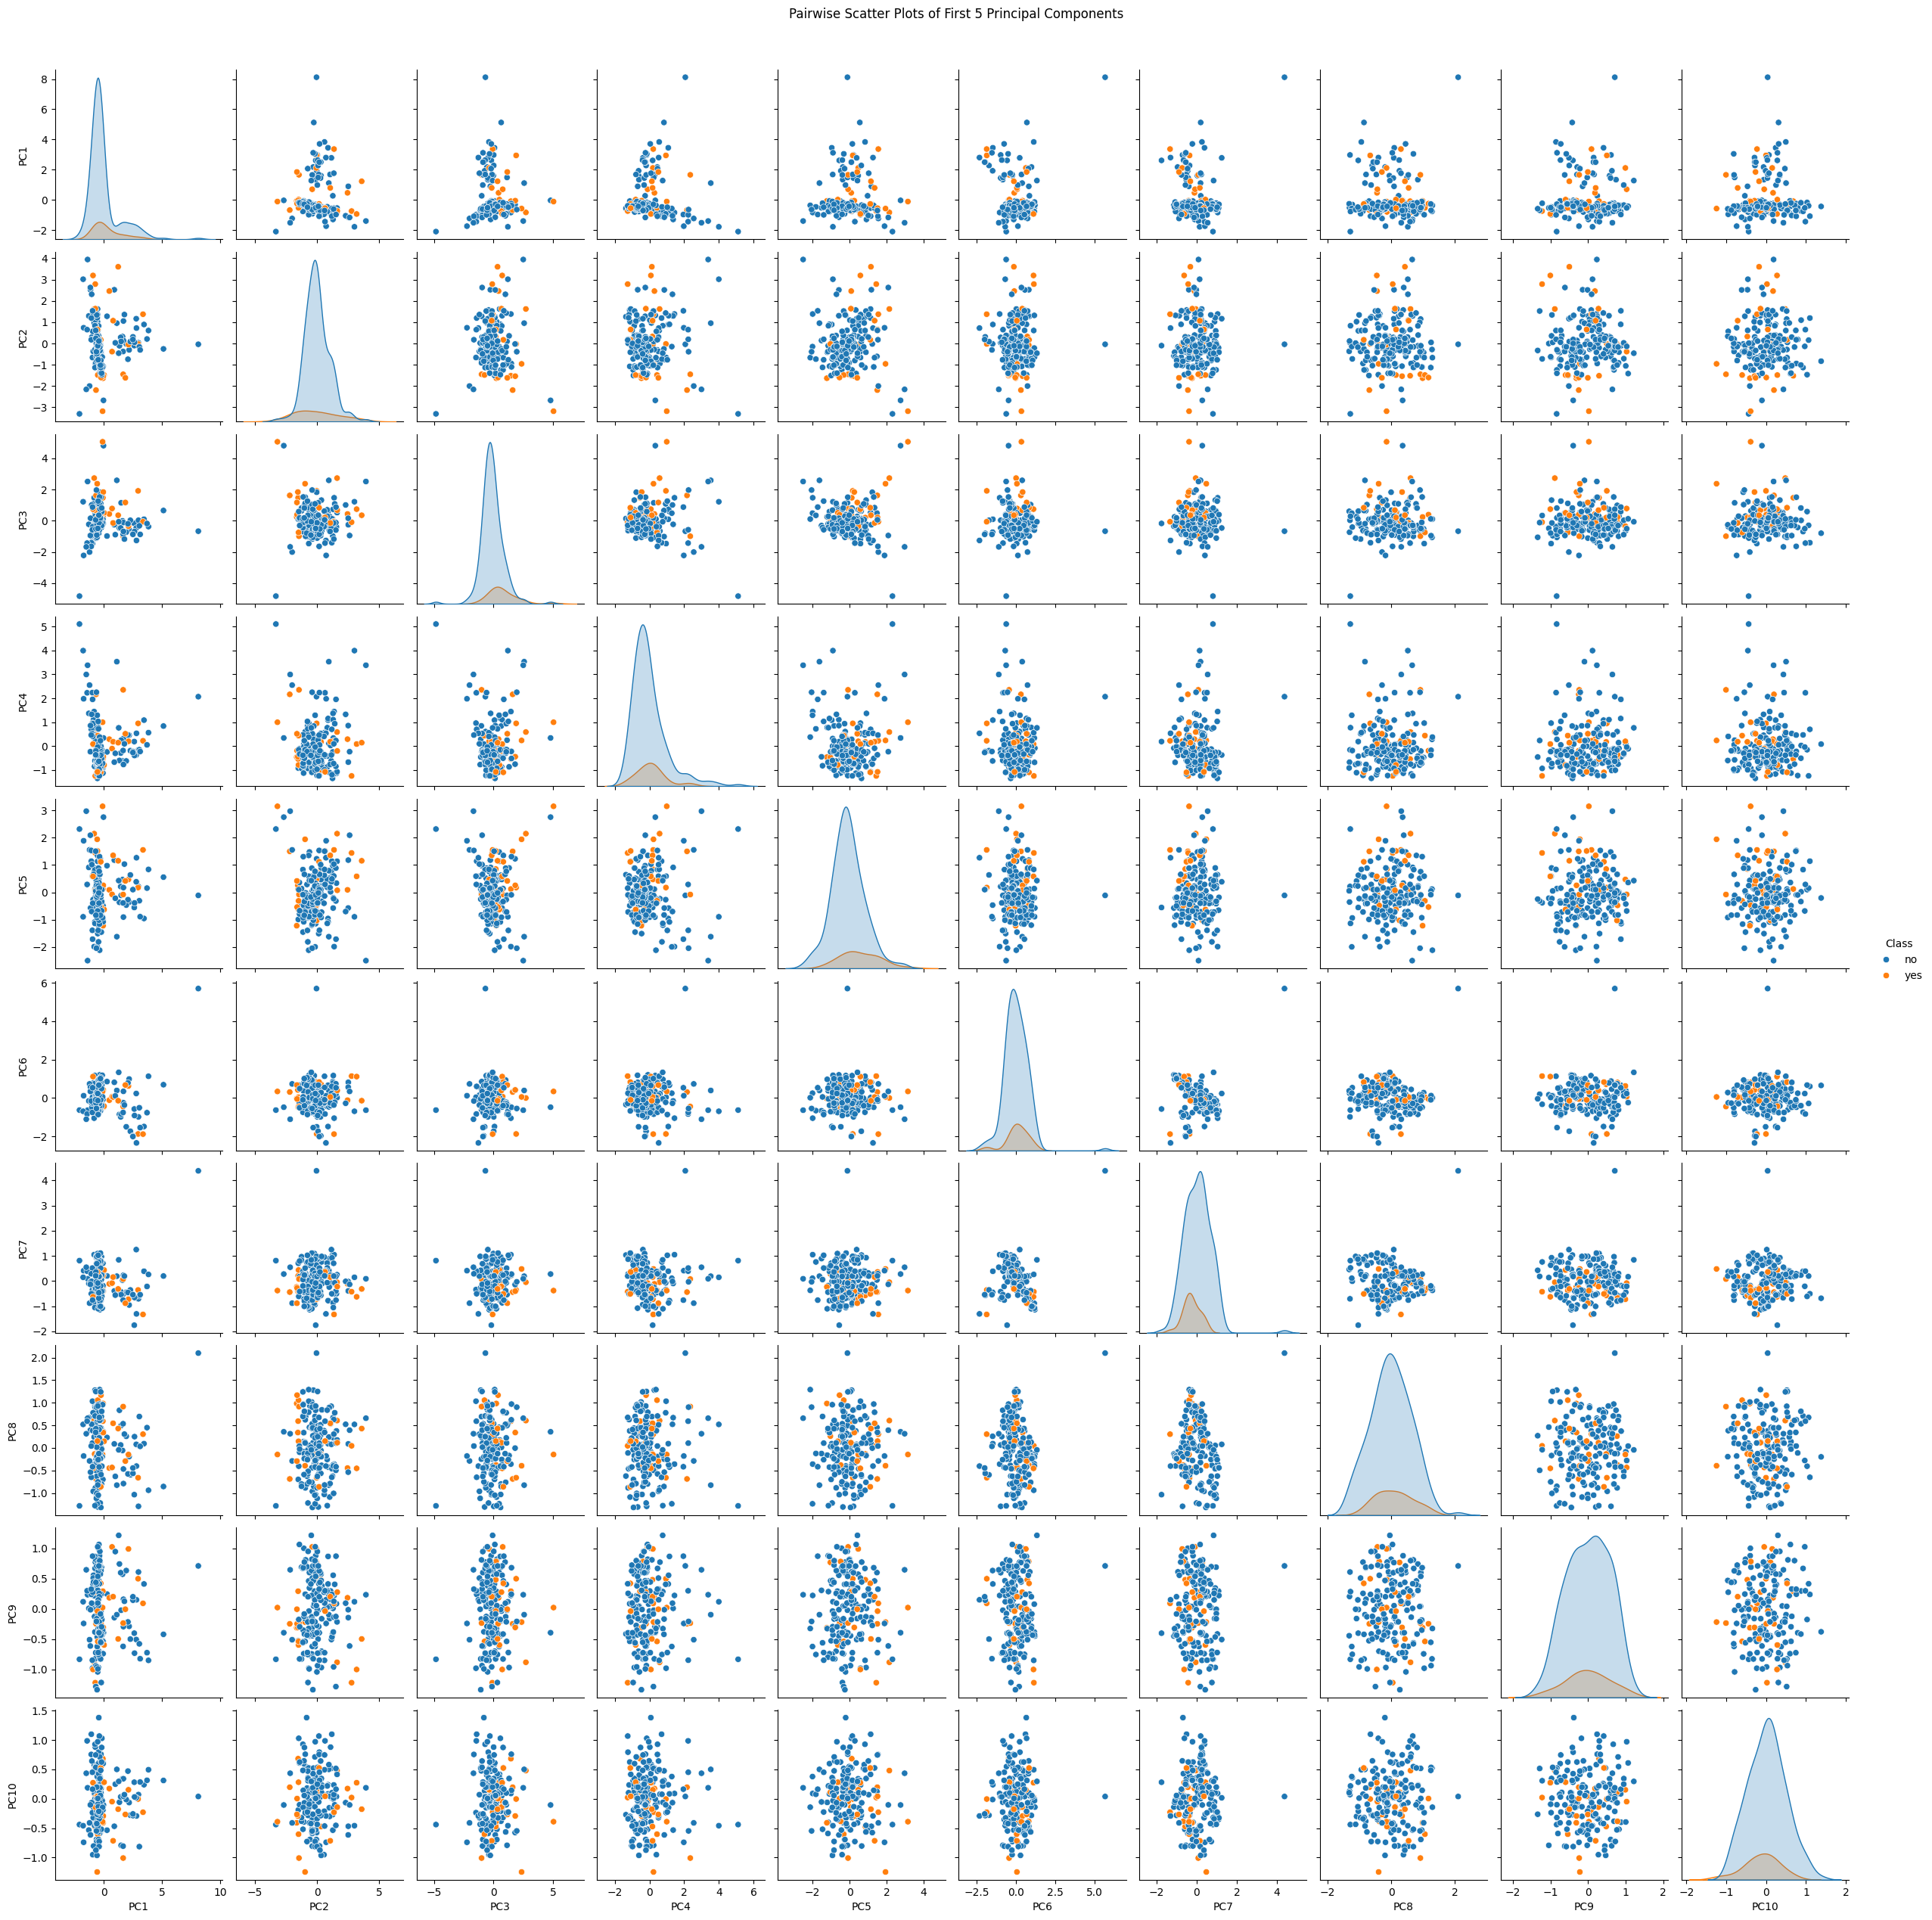

In [160]:
pca_df = pd.DataFrame(pca_result, columns=[f'PC{i+1}' for i in range(pca_result.shape[1])])
pca_df['Class'] = y

sns.pairplot(pca_df, hue="Class", diag_kind='kde')
plt.suptitle("Pairwise Scatter Plots of First 5 Principal Components", y=1.02)
plt.show()

In [161]:
pca_df = pd.DataFrame(data = pca_result, columns = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10'])
pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,-0.365158,-0.105789,-0.199053,-0.446692,-1.150425,0.377308,-0.181184,0.370971,0.879809,-0.400099
1,3.453875,0.890810,0.089740,1.083427,-0.959028,-1.483404,0.388376,0.093893,0.412021,0.238521
2,2.618231,-0.102315,-0.178161,0.185155,-0.556777,-0.571755,-1.754977,-1.036464,-0.402470,0.280801
3,-0.730984,-0.940040,-0.659764,0.604167,-0.235148,0.228259,0.062947,-0.886920,0.773459,0.077571
4,-0.551718,1.254364,0.132294,-1.356635,0.645770,-0.340619,1.032122,-0.624782,-0.415240,-0.271417


In [162]:
PCA_finalDf = pd.concat([pca_df, y], axis = 1)
PCA_finalDf.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,y
0,-0.365158,-0.105789,-0.199053,-0.446692,-1.150425,0.377308,-0.181184,0.370971,0.879809,-0.400099,no
1,3.453875,0.890810,0.089740,1.083427,-0.959028,-1.483404,0.388376,0.093893,0.412021,0.238521,no
2,2.618231,-0.102315,-0.178161,0.185155,-0.556777,-0.571755,-1.754977,-1.036464,-0.402470,0.280801,no
3,-0.730984,-0.940040,-0.659764,0.604167,-0.235148,0.228259,0.062947,-0.886920,0.773459,0.077571,no
4,-0.551718,1.254364,0.132294,-1.356635,0.645770,-0.340619,1.032122,-0.624782,-0.415240,-0.271417,no


In [163]:
X_PCA = PCA_finalDf.drop(columns=['y'])
y_PCA = PCA_finalDf['y']

In [164]:
X_train, X_test, y_train, y_test = train_test_split(X_PCA, y_PCA, test_size=0.3) # 70% training a

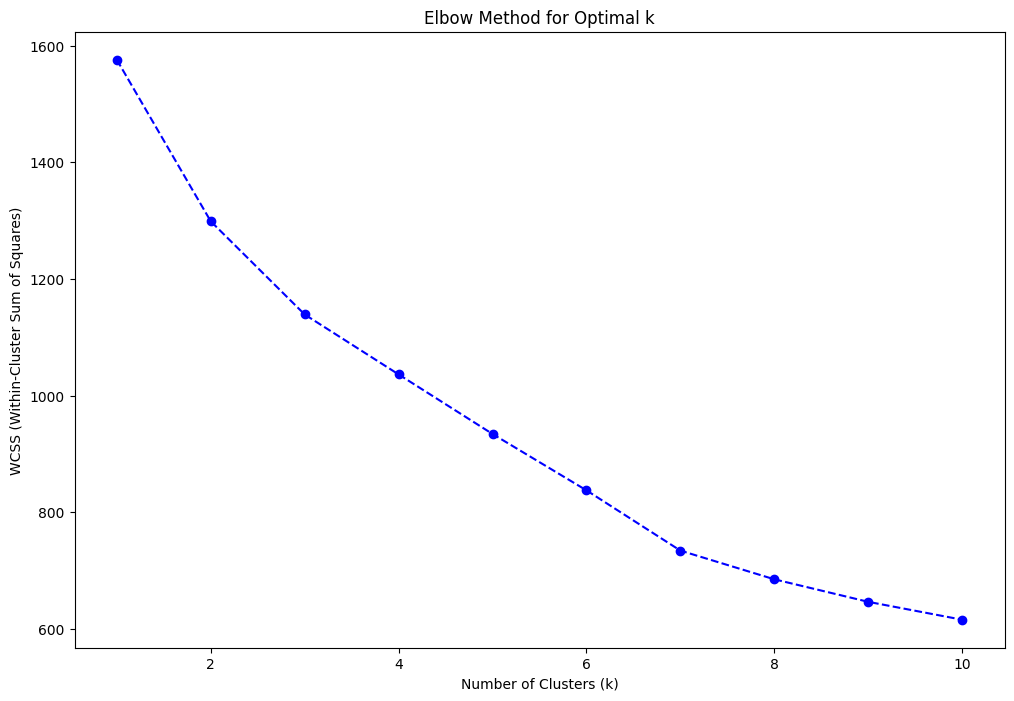

In [165]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_PCA)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(12,8))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal k')
plt.show()

In [166]:
# 7 looks like a good elbow
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_PCA)

PCA_finalDf['Cluster'] = clusters
PCA_finalDf.tail()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,y,Cluster
195,-0.698840,0.612975,0.056205,-0.370100,1.506554,-0.090049,0.206270,0.344029,-0.725929,0.744698,no,1
196,-0.483082,-0.768142,1.252461,1.029245,-1.396597,-0.859433,1.023460,-0.261516,-0.723086,-0.225776,no,0
197,-0.515285,-0.106351,-0.496739,-0.684512,-0.098366,-0.131223,-0.080782,0.927273,0.538018,0.005970,no,0
198,-0.424956,0.109567,0.349522,-0.642233,-0.022089,0.672725,-0.464593,-0.128139,0.710328,-0.214464,no,0
199,1.234334,3.603416,0.346477,0.138900,1.155025,-0.139530,-0.314737,0.428594,-0.498033,-0.177658,yes,1


In [172]:
silhouette_avg = silhouette_score(X_PCA, clusters)
print(f"Silhouette Score: {silhouette_avg:.4f}")

Silhouette Score: 0.2196


## Task 5 - Visualize the Plotting
- Plot and visualize the clustering of the data.

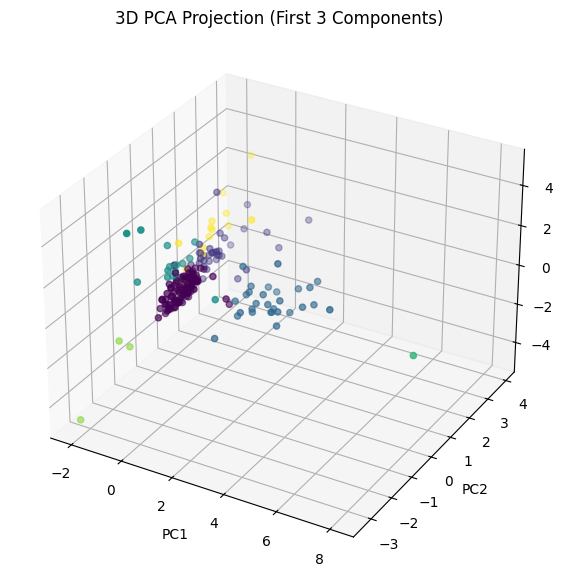

In [167]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(PCA_finalDf['PC1'], PCA_finalDf['PC2'], PCA_finalDf['PC3'], c=PCA_finalDf['Cluster'], cmap='viridis')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D PCA Projection (First 3 Components)')
plt.show()

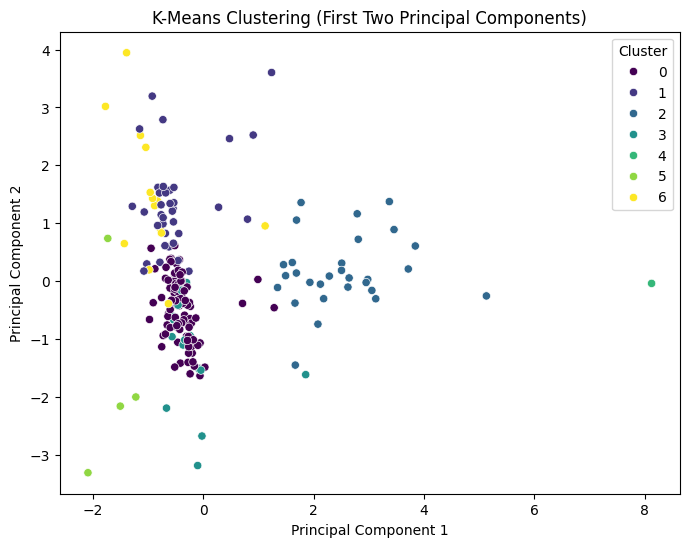

In [168]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=PCA_finalDf["PC1"], y=PCA_finalDf["PC2"], hue=PCA_finalDf["Cluster"], palette="viridis")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering (First Two Principal Components)")
plt.legend(title="Cluster")
plt.show()